# Cube-tower anisotropy comparison from phase

This notebook does one thing: compare the projected phase obtained after relaxing the cube with each of the 8 symmetry-equivalent `<111>` cubic-anisotropy directions.

There is no outer fit and no axis update. For each fixed direction, the same initial magnetization is relaxed with the BB/Cayley steepest-descent minimizer, the phase image is projected, and the result is compared directly to the saved cube target phase.

The lowest final phase loss is the best-matching fixed direction in this simple comparison.

In [1]:
from __future__ import annotations

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.1"

from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

import jax
import jax.numpy as jnp

cwd = Path.cwd().resolve()
repo_root = next((path for path in (cwd, *cwd.parents) if (path / "pyproject.toml").exists()), cwd)
vendor_neuralmag = repo_root / "vendor/neuralmag"
if vendor_neuralmag.exists() and str(vendor_neuralmag) not in sys.path:
    sys.path.insert(0, str(vendor_neuralmag))

from libertem_holo.base.mbir import (
    EquilibriumOrientationFitConfig,
    angular_distance_deg,
    build_equilibrium_orientation_problem,
    ensure_neuralmag_jax_backend,
    phase_from_relaxed_m,
    phase_loss_after_relax,
    prepare_equilibrium_fit_target_from_npz,
    unit_vector_to_axis_angles,
)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["image.origin"] = "lower"
np.set_printoptions(precision=4, suppress=True)

output_dir = repo_root / "notebooks/MBIR/neuralmag_cube_tower_outputs"
output_npz = output_dir / "cube_tower_relaxed_comparison.npz"
target_orientation_name = "1, 1, 1 Axis"
initial_magnetization_mode = "target"
random_magnetization_seed = 11
relaxation_method = "alternating"

reference_axes = {
    "0, 0, 1 Axis": np.array([0.0, 0.0, 1.0], dtype=np.float32),
    "1, 1, 1 Axis": np.array([1.0, 1.0, 1.0], dtype=np.float32) / np.sqrt(3.0),
}

_s = 1.0 / np.sqrt(3.0)
initial_axes_111 = np.array(
    [
        [+_s, +_s, +_s],
        [+_s, +_s, -_s],
        [+_s, -_s, +_s],
        [+_s, -_s, -_s],
        [-_s, +_s, +_s],
        [-_s, +_s, -_s],
        [-_s, -_s, +_s],
        [-_s, -_s, -_s],
    ],
    dtype=np.float32,
)


def _format_axis_label(axis: np.ndarray) -> str:
    parts = ["1" if component > 0 else "1bar" for component in axis]
    return "[" + "".join(parts) + "]"


initial_axis_labels = [_format_axis_label(axis) for axis in initial_axes_111]

comparison_config = EquilibriumOrientationFitConfig(
    coarse_grain_factor=2,
    support_threshold=0.5,
    demag_p=2,
    phase_pad=16,
    minimizer_tol=1e3,
    minimizer_relative_tol=1e-2,
    minimizer_min_iter=32,
    minimizer_stall_patience=512,
    minimizer_stall_relative_improvement=1e-5,
    minimizer_max_iter=4096,
)

material = dict(
    Msat_A_per_m=480e3,
    Aex_J_per_m=1e-11,
    Kc1_J_per_m3=-1.35e4,
)

print(f"Target orientation: {target_orientation_name}")
print(f"Source coarse-grain factor: {comparison_config.coarse_grain_factor}x")
print(f"Phase pad: {comparison_config.phase_pad} coarse pixels per side")
print(f"Initial m mode: {initial_magnetization_mode}")
if initial_magnetization_mode == "random":
    print(f"Initial m seed: {random_magnetization_seed}")
print(f"Fixed-axis comparison: {len(initial_axes_111)} <111> candidate directions (vmapped)")
print(
    "Relaxer: BB/Cayley steepest descent with "
    f"method={relaxation_method}, max_iter={comparison_config.minimizer_max_iter}, "
    f"stall_patience={comparison_config.minimizer_stall_patience}"
)

Target orientation: 1, 1, 1 Axis
Source coarse-grain factor: 2x
Phase pad: 16 coarse pixels per side
Initial m mode: target
Fixed-axis comparison: 8 <111> candidate directions (vmapped)
Relaxer: BB/Cayley steepest descent with method=alternating, max_iter=4096, stall_patience=512


In [2]:
nm = ensure_neuralmag_jax_backend()
backend_name = getattr(getattr(nm, "config", None), "backend", None)
backend_name = getattr(backend_name, "name", backend_name)

if not output_npz.exists():
    raise FileNotFoundError(f"Missing saved cube-tower output: {output_npz}")

target = prepare_equilibrium_fit_target_from_npz(
    output_npz,
    target_orientation_name,
    config=comparison_config,
)
problem = build_equilibrium_orientation_problem(
    target,
    config=comparison_config,
    **material,
)

true_axis = reference_axes.get(target.name)
phase_target = np.asarray(target.phase_target, dtype=np.float32)

direct_phase = np.asarray(
    phase_from_relaxed_m(problem, jnp.asarray(target.m_xyz, dtype=jnp.float32)),
    dtype=np.float32,
)
direct_residual = direct_phase - phase_target
direct_phase_loss = float(0.5 * np.mean(direct_residual * direct_residual))
direct_phase_rms = float(np.sqrt(np.mean(direct_residual * direct_residual)))

support_mask = np.asarray(target.rho_xyz > comparison_config.support_threshold)
if initial_magnetization_mode == "random":
    rng = np.random.default_rng(random_magnetization_seed)
    m0_xyz = rng.normal(size=target.m_xyz.shape).astype(np.float32)
    norms = np.linalg.norm(m0_xyz, axis=-1, keepdims=True)
    m0_xyz = np.where(
        support_mask[..., None],
        m0_xyz / np.maximum(norms, 1e-12),
        0.0,
    ).astype(np.float32)
elif initial_magnetization_mode == "target":
    m0_xyz = np.asarray(target.m_xyz, dtype=np.float32)
else:
    raise ValueError(
        "initial_magnetization_mode must be 'target' or 'random', "
        f"got {initial_magnetization_mode!r}."
    )

init_angles_batch = jnp.asarray(
    [unit_vector_to_axis_angles(axis) for axis in initial_axes_111],
    dtype=jnp.float32,
)
m0_shared = jnp.asarray(m0_xyz, dtype=jnp.float32)


def compare_one_direction(axis_angles):
    loss, aux = phase_loss_after_relax(
        problem,
        axis_angles,
        m0_shared,
        method=relaxation_method,
    )
    return (
        loss.astype(jnp.float32),
        aux["phase_rms"].astype(jnp.float32),
        aux["phase_pred"].astype(jnp.float32),
        aux["n_iter"].astype(jnp.int32),
        aux["max_g"].astype(jnp.float32),
        aux["target_max_g"].astype(jnp.float32),
        aux["converged"],
    )


run_all_directions = jax.jit(jax.vmap(compare_one_direction))

started = time.perf_counter()
loss_batch, rms_batch, phase_pred_batch, n_iter_batch, max_g_batch, target_max_g_batch, converged_batch = run_all_directions(
    init_angles_batch
)
_ = loss_batch.block_until_ready()
elapsed_s = time.perf_counter() - started

loss_batch_np = np.asarray(loss_batch, dtype=np.float32)
rms_batch_np = np.asarray(rms_batch, dtype=np.float32)
phase_pred_batch_np = np.asarray(phase_pred_batch, dtype=np.float32)
n_iter_batch_np = np.asarray(n_iter_batch, dtype=np.int32)
max_g_batch_np = np.asarray(max_g_batch, dtype=np.float32)
target_max_g_batch_np = np.asarray(target_max_g_batch, dtype=np.float32)
converged_batch_np = np.asarray(converged_batch, dtype=bool)

has_converged = bool(np.any(converged_batch_np))
if has_converged:
    best_idx = int(np.argmin(np.where(converged_batch_np, loss_batch_np, np.inf)))
    best_selection = "best converged direction"
else:
    best_idx = int(np.argmin(loss_batch_np))
    best_selection = "best direction (no converged run)"

best_phase = phase_pred_batch_np[best_idx]
best_residual = best_phase - phase_target

comparison_summary = []
for idx, label in enumerate(initial_axis_labels):
    comparison_summary.append(
        {
            "label": label,
            "loss": float(loss_batch_np[idx]),
            "phase_rms": float(rms_batch_np[idx]),
            "n_iter": int(n_iter_batch_np[idx]),
            "max_g": float(max_g_batch_np[idx]),
            "target_max_g": float(target_max_g_batch_np[idx]),
            "converged": bool(converged_batch_np[idx]),
            "angle_to_truth_deg": (
                angular_distance_deg(initial_axes_111[idx], true_axis) if true_axis is not None else None
            ),
        }
    )
comparison_summary.sort(key=lambda row: (not row["converged"], row["loss"]))

best_result = {
    "selection": best_selection,
    "index": best_idx,
    "label": initial_axis_labels[best_idx],
    "axis": initial_axes_111[best_idx],
    "loss": float(loss_batch_np[best_idx]),
    "phase_rms": float(rms_batch_np[best_idx]),
    "n_iter": int(n_iter_batch_np[best_idx]),
    "max_g": float(max_g_batch_np[best_idx]),
    "target_max_g": float(target_max_g_batch_np[best_idx]),
    "converged": bool(converged_batch_np[best_idx]),
}

print(f"NeuralMag backend: {backend_name}")
print(f"JAX backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"Coarse XYZ shape: {target.rho_xyz.shape}; coarse cell size: {target.cellsize_nm:g} nm")
print(f"Phase target shape: {target.phase_target.shape}")
print(
    f"Direct phase check from saved target m: loss={direct_phase_loss:.6g}, "
    f"rms={direct_phase_rms:.6g}"
)
print(
    f"Vmapped fixed-axis comparison: {len(initial_axes_111)} directions in {elapsed_s:.2f}s"
)
print(
    f"Selected result: {best_result['selection']} -> {best_result['label']} | "
    f"loss={best_result['loss']:.6g} | phase_rms={best_result['phase_rms']:.6g} | "
    f"n_iter={best_result['n_iter']} | converged={best_result['converged']}"
)
if true_axis is not None:
    print(
        f"Selected-direction angular error: "
        f"{angular_distance_deg(best_result['axis'], true_axis):.3f} deg"
    )

2026-04-27 12:29:58 NeuralMag:INFO [NeuralMag] Version 0.9.4
2026-04-27 12:29:58 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
/Users/landers/neuralmag/.venv-notebook/lib/python3.12/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/Users/landers/LiberTEM-holo/src/libertem_holo/base/mbir/kernel.py:140: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  coeff_val = jnp.as

NeuralMag backend: jax
JAX backend: gpu | devices: [CudaDevice(id=0)]
Coarse XYZ shape: (56, 171, 28); coarse cell size: 6 nm
Phase target shape: (203, 88)
Direct phase check from saved target m: loss=0, rms=0
Vmapped fixed-axis comparison: 8 directions in 51.10s
Selected result: best converged direction -> [1bar11] | loss=39.4741 | phase_rms=8.88527 | n_iter=767 | converged=True
Selected-direction angular error: 70.529 deg


In [3]:
for rank, row in enumerate(comparison_summary, start=1):
    angle_text = (
        f" | angle_to_truth={row['angle_to_truth_deg']:.3f} deg"
        if row["angle_to_truth_deg"] is not None
        else ""
    )
    print(
        f"{rank:>2}. {row['label']:<14} "
        f"loss={row['loss']:.6g} | rms={row['phase_rms']:.6g} | "
        f"n_iter={row['n_iter']:>4} | converged={row['converged']}"
        f"{angle_text}"
    )

comparison_summary

 1. [1bar11]       loss=39.4741 | rms=8.88527 | n_iter= 767 | converged=True | angle_to_truth=70.529 deg
 2. [111]          loss=39.4803 | rms=8.88597 | n_iter= 869 | converged=True | angle_to_truth=0.000 deg
 3. [11bar1bar]    loss=39.4818 | rms=8.88615 | n_iter= 642 | converged=True | angle_to_truth=70.529 deg
 4. [1bar1bar1bar] loss=39.488 | rms=8.88685 | n_iter= 833 | converged=True | angle_to_truth=0.000 deg
 5. [11bar1]       loss=39.4921 | rms=8.88731 | n_iter= 785 | converged=True | angle_to_truth=70.529 deg
 6. [1bar1bar1]    loss=39.4968 | rms=8.88783 | n_iter=1003 | converged=True | angle_to_truth=70.529 deg
 7. [111bar]       loss=39.4968 | rms=8.88783 | n_iter= 860 | converged=True | angle_to_truth=70.529 deg
 8. [1bar11bar]    loss=39.4992 | rms=8.8881 | n_iter= 654 | converged=True | angle_to_truth=70.529 deg


[{'label': '[1bar11]',
  'loss': 39.47405242919922,
  'phase_rms': 8.885274887084961,
  'n_iter': 767,
  'max_g': 3044.72705078125,
  'target_max_g': 3270.67578125,
  'converged': True,
  'angle_to_truth_deg': 70.52877513954532},
 {'label': '[111]',
  'loss': 39.48025894165039,
  'phase_rms': 8.88597297668457,
  'n_iter': 869,
  'max_g': 3005.51513671875,
  'target_max_g': 3228.97314453125,
  'converged': True,
  'angle_to_truth_deg': 0.0},
 {'label': '[11bar1bar]',
  'loss': 39.48183059692383,
  'phase_rms': 8.886150360107422,
  'n_iter': 642,
  'max_g': 3228.011962890625,
  'target_max_g': 3270.67578125,
  'converged': True,
  'angle_to_truth_deg': 70.52877513954532},
 {'label': '[1bar1bar1bar]',
  'loss': 39.4880256652832,
  'phase_rms': 8.886847496032715,
  'n_iter': 833,
  'max_g': 3133.967041015625,
  'target_max_g': 3228.97314453125,
  'converged': True,
  'angle_to_truth_deg': 0.0},
 {'label': '[11bar1]',
  'loss': 39.492122650146484,
  'phase_rms': 8.887308120727539,
  'n_iter

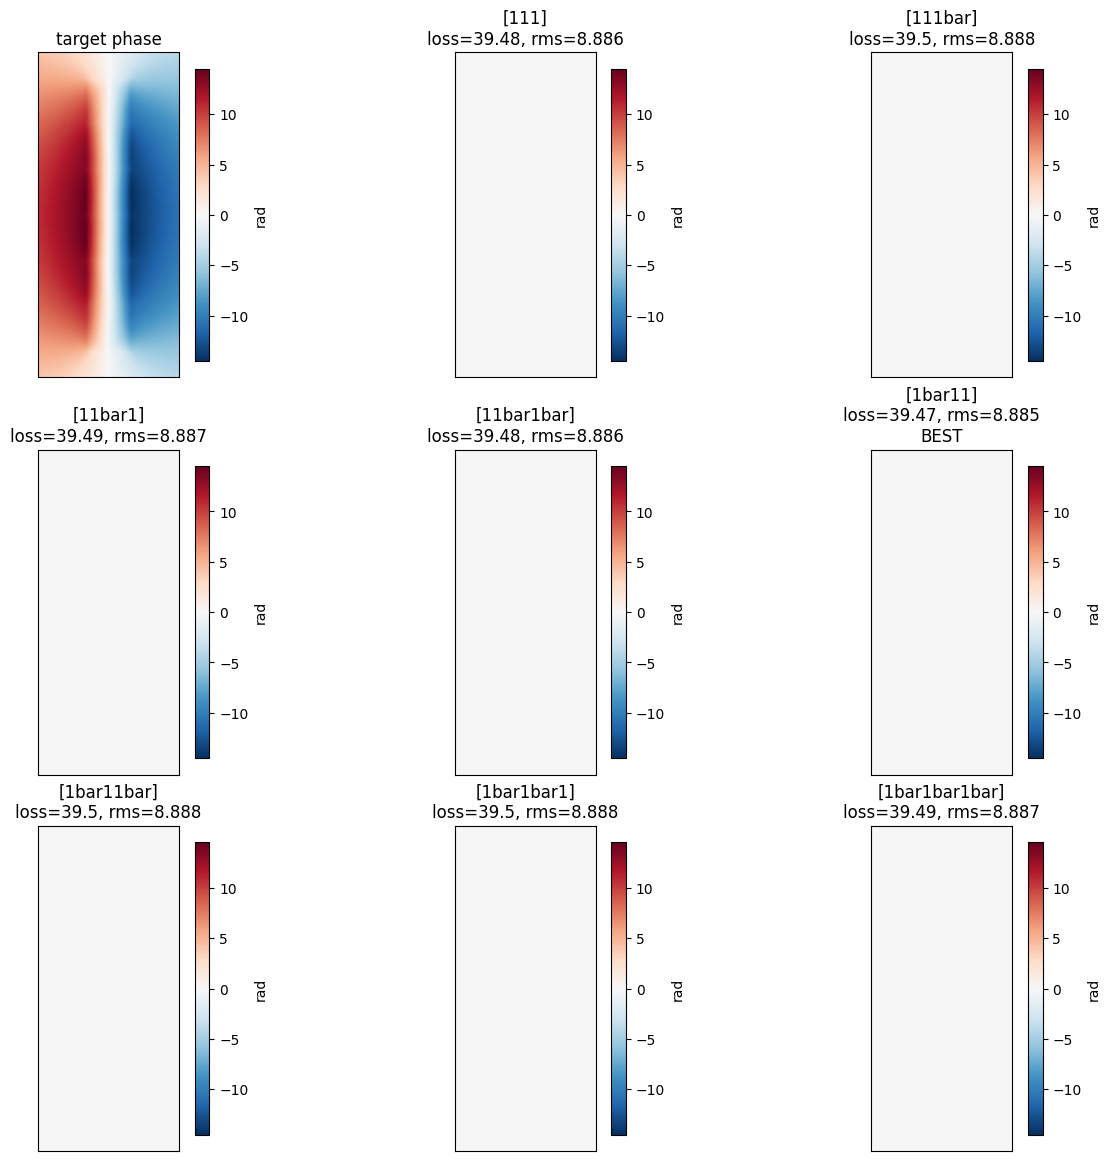

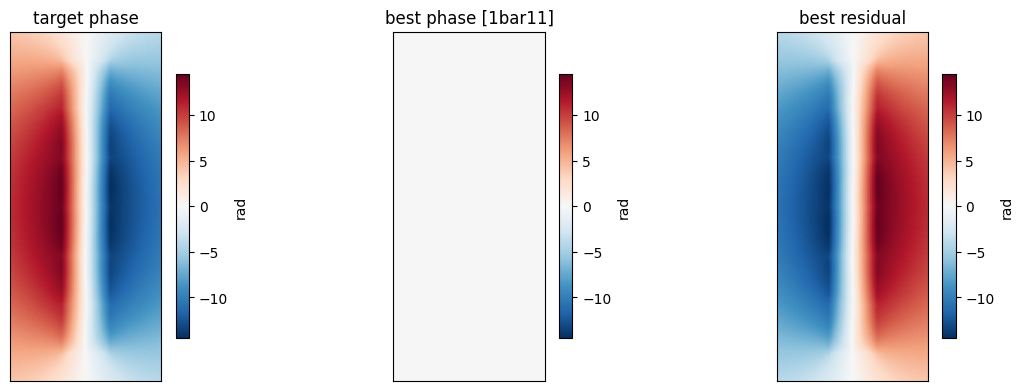

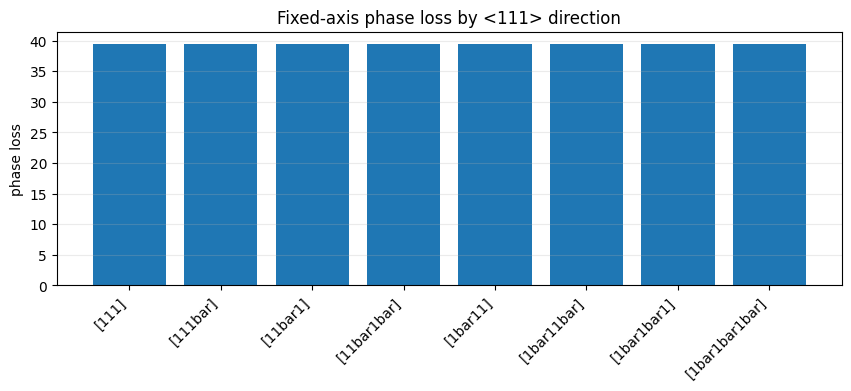

: 

In [ ]:
phase_vmax = max(
    abs(float(phase_target.min())),
    abs(float(phase_target.max())),
    abs(float(phase_pred_batch_np.min())),
    abs(float(phase_pred_batch_np.max())),
    1e-12,
)

fig, axes = plt.subplots(3, 3, figsize=(12.5, 11.5), constrained_layout=True)
panels = [("target phase", phase_target, None)] + [
    (initial_axis_labels[idx], phase_pred_batch_np[idx], idx)
    for idx in range(len(initial_axis_labels))
]

for ax, (title, image, idx) in zip(axes.flat, panels):
    im = ax.imshow(image, cmap="RdBu_r", vmin=-phase_vmax, vmax=phase_vmax)
    if idx is None:
        ax.set_title(title)
    else:
        best_marker = "\nBEST" if idx == best_result["index"] else ""
        ax.set_title(
            f"{title}\nloss={loss_batch_np[idx]:.4g}, rms={rms_batch_np[idx]:.4g}{best_marker}"
        )
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, label="rad")

plt.show()

residual_vmax = max(abs(float(best_residual.min())), abs(float(best_residual.max())), 1e-12)
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8), constrained_layout=True)
for ax, image, title, limit in [
    (axes[0], phase_target, "target phase", phase_vmax),
    (axes[1], best_phase, f"best phase {best_result['label']}", phase_vmax),
    (axes[2], best_residual, "best residual", residual_vmax),
]:
    im = ax.imshow(image, cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, label="rad")
plt.show()

fig, ax = plt.subplots(figsize=(8.4, 3.8), constrained_layout=True)
ax.bar(np.arange(len(initial_axis_labels)), loss_batch_np)
ax.set_xticks(np.arange(len(initial_axis_labels)), initial_axis_labels, rotation=45, ha="right")
ax.set_ylabel("phase loss")
ax.set_title("Fixed-axis phase loss by <111> direction")
ax.grid(True, axis="y", alpha=0.25)
plt.show()